<a href="https://colab.research.google.com/github/DebiSaputra26/Model/blob/main/23_11_5480.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : DEBI SAPUTRA
NIM : 23.11.5480

judul Project : Prediksi Kebutuhan Servis Motor Menggunakan Metode Decision Tree Berdasarkan Data Riwayat Perawatan



1.Pengumpulan Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Memuat dataset (Pastikan file CSV berada di folder yang sama)
try:
    data = pd.read_csv('dataset_servis_motor_lengkap.csv')
    print("Dataset berhasil dimuat!")
except:
    print("File CSV tidak ditemukan, pastikan nama file benar.")

# Menampilkan 5 data teratas
data.head()

Dataset berhasil dimuat!


,kilometer,umur_motor,hari_sejak_servis,pemakaian,jenis_oli,kondisi_mesin,perlu_servis
0,20466,2,208,2,1,0,1
1,16225,12,331,2,1,1,1
2,28530,6,153,0,0,2,1
3,18230,5,33,2,1,1,1
4,29136,9,310,1,1,2,1


2. Analisis Data Eksploratif (EDA)

          kilometer  umur_motor  hari_sejak_servis   pemakaian   jenis_oli  \
count    300.000000  300.000000         300.000000  300.000000  300.000000   
mean   15944.850000    6.953333         183.080000    0.943333    0.496667   
std     8200.877726    4.546801         108.625035    0.838131    0.500824   
min      596.000000    0.000000           1.000000    0.000000    0.000000   
25%     9352.000000    3.000000          94.000000    0.000000    0.000000   
50%    16278.500000    7.000000         183.000000    1.000000    0.000000   
75%    22379.500000   11.000000         271.750000    2.000000    1.000000   
max    29927.000000   14.000000         364.000000    2.000000    1.000000   

       kondisi_mesin  perlu_servis  
count     300.000000    300.000000  
mean        1.000000      0.953333  
std         0.813761      0.211276  
min         0.000000      0.000000  
25%         0.000000      1.000000  
50%         1.000000      1.000000  
75%         2.000000      1.000000  
m

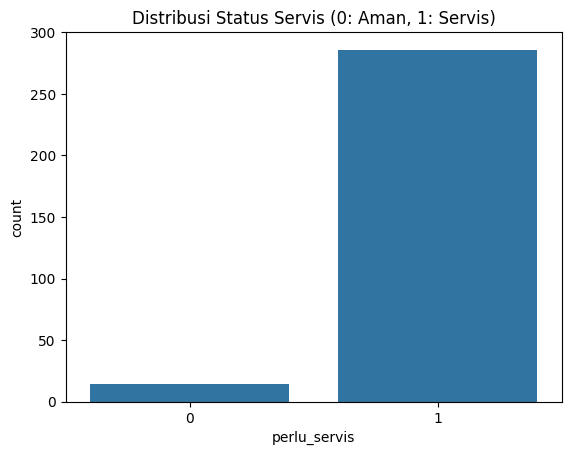

In [ ]:
# Statistik deskriptif untuk melihat rentang kilometer, umur, dll
print(data.describe())

# Visualisasi jumlah motor yang perlu servis vs aman
sns.countplot(x='perlu_servis', data=data)
plt.title('Distribusi Status Servis (0: Aman, 1: Servis)')
plt.show()

3. Praproses Data

In [ ]:
# 1. Membersihkan data dari nilai kosong (Missing Values) di awal
# Penting dilakukan sebelum memisahkan X dan y agar jumlah baris tetap sinkron
data = data.dropna()

# 2. Pemilihan Fitur (X) - Faktor yang mempengaruhi keputusan servis
# Diambil dari kolom: kilometer, umur motor, hari sejak terakhir servis, dan intensitas pemakaian
X = data[['kilometer', 'umur_motor', 'hari_sejak_servis', 'pemakaian']]

# 3. Pemilihan Target (y) - Apa yang ingin kita tebak?
# Yaitu status 'perlu_servis' (0 atau 1)
y = data['perlu_servis']

# 4. Verifikasi hasil preprocessing
print("--- Hasil Preprocessing ---")
print(f"Total baris data setelah dibersihkan: {len(data)}")
print(f"Fitur yang digunakan: {list(X.columns)}")

--- Hasil Preprocessing ---
Total baris data setelah dibersihkan: 300
Fitur yang digunakan: ['kilometer', 'umur_motor', 'hari_sejak_servis', 'pemakaian']


4. Pelacakan (Pemisahan) Kumpulan Data

In [ ]:
# Membagi data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 240
Jumlah data testing: 60


5. Pemodelan & Evaluasi

In [ ]:
# Inisialisasi dan pelatihan model
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Evaluasi model dengan data testing
y_pred = model.predict(X_test)
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi Model: 93.33%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.95      0.98      0.96        54

    accuracy                           0.93        60
   macro avg       0.85      0.74      0.78        60
weighted avg       0.93      0.93      0.93        60



6. Prediksi

------------------------------
HASIL: Motor PERLU SERVIS rutin.
------------------------------


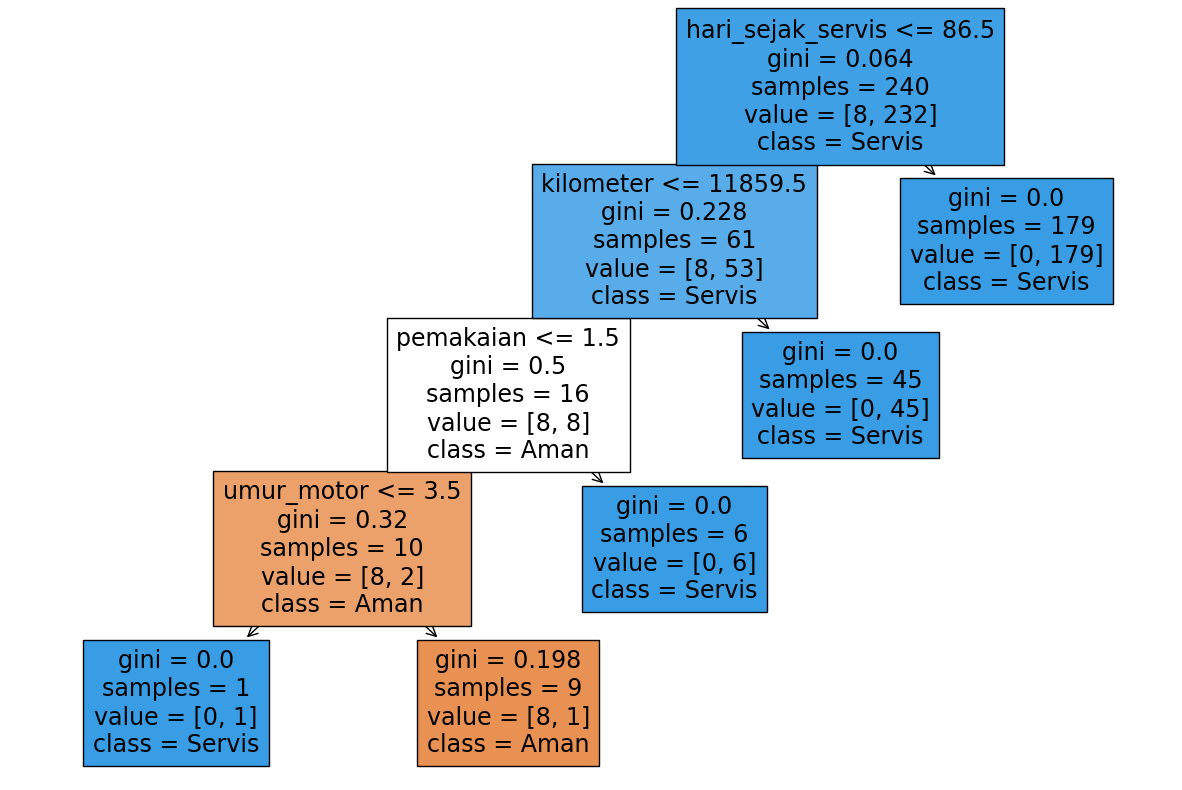

In [ ]:
# km: 15000, umur: 4th, hari: 120, pemakaian: 2 (tinggi)
data_motor_baru = pd.DataFrame([{
    'kilometer': 15000,
    'umur_motor': 4,
    'hari_sejak_servis': 120,
    'pemakaian': 2
}])

# Eksekusi Prediksi
prediksi = model.predict(data_motor_baru)

print("-" * 30)
if prediksi[0] == 1:
    print("HASIL: Motor PERLU SERVIS rutin.")
else:
    print("HASIL: Motor masih dalam kondisi AMAN.")
print("-" * 30)

# Visualisasi Logika Decision Tree (Opsional)
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, class_names=['Aman', 'Servis'], filled=True)
plt.show()